# Stage 5 — IDM-VTON Pre-trained Inference

**What we built so far:**
- Stage 1: Pose skeleton (MediaPipe Tasks API)
- Stage 2: Body segmentation → cloth-agnostic person + erase mask (SegFormer)
- Stage 3: Clothing placement from erase mask bounding box
- Stage 4: Poisson blending + histogram matching → seamless composite

**Stage 4's limitation:** Poisson blending is a classical method. It desaturates colour and can't reconstruct realistic fabric wrinkles or lighting interactions.

**Stage 5 upgrade:** Run [IDM-VTON](https://github.com/yisol/IDM-VTON) — a state-of-the-art **diffusion model** trained specifically for virtual try-on. It replaces our Poisson blend with learned, photorealistic synthesis.

---

### How IDM-VTON works

IDM-VTON extends **Stable Diffusion XL (SDXL)** inpainting with two innovations:

1. **Garment Net** — a second UNet that encodes the garment image. Its features are injected into the main UNet via **IP-Adapter cross-attention**, so the model "sees" fine garment details (texture, print, collar shape) during denoising.
2. **Try-on Net** — the main SDXL inpainting UNet conditioned on:
   - Cloth-agnostic person image (shirt erased)
   - Binary mask of the clothing region
   - Pose skeleton image
   - Garment features from the Garment Net

Our Stage 1-4 outputs map **directly** to these inputs:

| IDM-VTON input | Our output |
|---|---|
| Cloth-agnostic person | `agnostic_person.png` (Stage 2) |
| Inpainting mask | `erase_mask.png` (Stage 2) |
| Pose skeleton | `pose_output.jpg` (Stage 1) |
| Garment image | `clothing.jpg` (our input) |

We skip IDM-VTON's internal preprocessing because we already did it in Stages 1-3.

> **IMPORTANT: Use a FRESH Colab runtime** — Runtime → Factory reset runtime before running. This avoids the broken system `huggingface_hub` that caused issues in Stages 1-4.

In [ ]:
# Sanity check: confirm we have a T4 GPU and enough VRAM
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. Runtime > Change runtime type > T4 GPU")

gpu_name = torch.cuda.get_device_name(0)
total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU   : {gpu_name}")
print(f"VRAM  : {total_vram:.1f} GB")
print()
if total_vram < 14:
    print("WARNING: IDM-VTON (SDXL) needs ~12 GB. Less than 14 GB may OOM.")
    print("         If you hit OOM, re-run the pipeline cell with cpu_offload=True")
else:
    print("VRAM looks sufficient. Memory tricks (xformers + attention slicing) will be enabled.")

GPU   : Tesla T4
VRAM  : 15.6 GB

VRAM looks sufficient. Memory tricks (xformers + attention slicing) will be enabled.


## 1. Install Dependencies

We install `huggingface_hub` first to pin a known-good version before anything else imports it (avoids the Colab system version conflict from Stage 4).

**xformers** provides memory-efficient attention — crucial for fitting SDXL on a T4.

In [ ]:
# ── INSTALL CELL — run once, then skip after restart ──────────────────────────
# After this cell finishes it kills the Python process so the new packages load
# cleanly. Colab will show "session crashed" — reconnect and continue from the
# next cell (GPU check). Do NOT re-run this cell after restart.

!pip install -q huggingface_hub==0.22.2          # pin before diffusers pulls its own version
!pip install -q diffusers==0.28.2 transformers==4.40.2 accelerate==0.30.0
!pip install -q xformers                          # memory-efficient attention for T4
!pip install -q kagglehub omegaconf einops safetensors
!pip install -q "Pillow>=9,<12" opencv-python
# NOTE: numpy is intentionally NOT pinned — Colab Python 3.12 uses numpy 2.x
#       natively; downgrading it breaks the ABI without a restart.

print("Packages installed. Restarting runtime now...")
import os, time
time.sleep(1)   # let the print flush
os.kill(os.getpid(), 9)  # force runtime restart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 25.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.22.2 which is incompatible.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.22.2 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.22.2 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.22.2 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.22.2 which is incompatible.
sentence-transformers 5.4.1 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.22.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 10.8 MB/

In [1]:
# ── START HERE after the runtime restarts ─────────────────────────────────────
# Verify that freshly installed packages are active.
# If you see an ImportError here, re-run the install cell and wait for restart.
import importlib
for pkg in ["diffusers", "transformers", "accelerate", "huggingface_hub", "torch", "numpy"]:
    mod = importlib.import_module(pkg)
    print(f"{pkg:20s} {mod.__version__}")

diffusers            0.28.2


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

transformers         4.40.2
accelerate           0.30.0
huggingface_hub      0.22.2
torch                2.10.0+cu128
numpy                2.0.2


## 2. Mount Google Drive + Load Stage 1-4 Outputs

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  person       (561, 1280)  mode=RGB
  cloth        (360, 360)  mode=RGB
  agnostic     (561, 1280)  mode=RGB
  mask         (561, 1280)  mode=L
  pose         (561, 1280)  mode=RGB


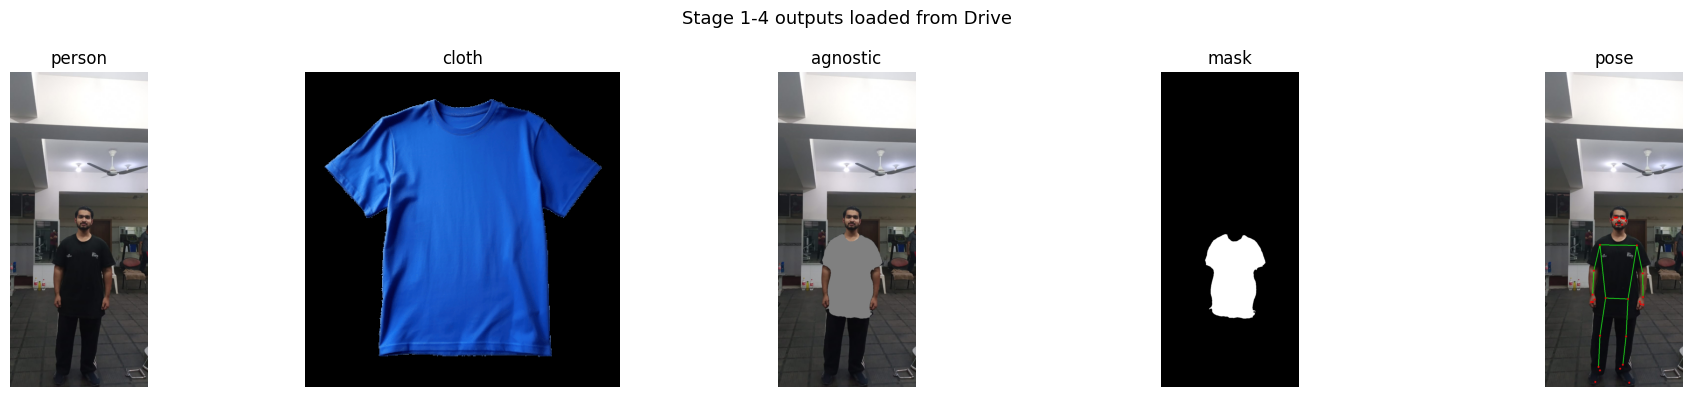

In [2]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

DRIVE      = "/content/drive/MyDrive/VirtualTryOn"
INPUT_DIR  = f"{DRIVE}/input_images"
OUTPUT_DIR = f"{DRIVE}/output_images"
CKPT_DIR   = f"{DRIVE}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# Load all Stage 1-4 outputs
person_img   = Image.open(f"{INPUT_DIR}/test_person.jpg").convert("RGB")
cloth_img    = Image.open(f"{INPUT_DIR}/clothing.jpg").convert("RGB")
agnostic_img = Image.open(f"{OUTPUT_DIR}/agnostic_person.png").convert("RGB")
mask_img     = Image.open(f"{OUTPUT_DIR}/erase_mask.png").convert("L")
pose_img     = Image.open(f"{OUTPUT_DIR}/pose_output.jpg").convert("RGB")

images = {
    "person": person_img, "cloth": cloth_img,
    "agnostic": agnostic_img, "mask": mask_img, "pose": pose_img,
}
for name, img in images.items():
    print(f"  {name:12s} {img.size}  mode={img.mode}")

# Quick preview
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax.set_title(name)
    ax.axis('off')
plt.suptitle("Stage 1-4 outputs loaded from Drive", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Download VITON-HD Dataset

VITON-HD is the standard benchmark for virtual try-on. It contains 1,024 test pairs with:
- `image/` — full person photos at 768×1024
- `cloth/` — product garment shots
- `agnostic-v3.2/` — pre-computed cloth-agnostic person (like our Stage 2 output)
- `agnostic-mask/` — pre-computed erase masks (like our Stage 2 output)
- `openpose-img/` — pre-computed DWPose skeletons (like our Stage 1 output)

We **won't save this to Drive** (it's ~10 GB). We download it fresh each session.

**Learning insight:** Compare the dataset's `agnostic-v3.2/` with our `agnostic_person.png` — they should look similar. This validates that Stages 1-3 are producing the right intermediate representations.

In [2]:
# Set Kaggle token and download VITON-HD
os.environ['KAGGLE_TOKEN'] = 'KGAT_fbc21b5329e8cbe6a20395ed9e25c159'
import kagglehub

print("Downloading VITON-HD dataset (~10 GB, takes 5-10 min on Colab)...")
dataset_path = kagglehub.dataset_download("marquis03/high-resolution-viton-zalando-dataset")
print(f"\nDataset downloaded to: {dataset_path}")

100%|██████████| 4.39G/4.39G [04:27<00:00, 17.6MB/s]

Extracting files...



Dataset downloaded to: /root/.cache/kagglehub/datasets/marquis03/high-resolution-viton-zalando-dataset/versions/1


In [7]:
# Explore the dataset structure
print("Top-level folders:")
for item in sorted(os.listdir(dataset_path)):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        print(f"  {item}/")
        for sub in sorted(os.listdir(item_path)):
            sub_path = os.path.join(item_path, sub)
            if os.path.isdir(sub_path):
                n = len(os.listdir(sub_path))
                print(f"    {sub}/  ({n} files)")

# Build paths to the test split
# Try common VITON-HD folder layouts
test_base = None
for candidate in ["test", "zalando-hd-resized/test", "viton-hd/test"]:
    p = os.path.join(dataset_path, candidate)
    if os.path.isdir(p):
        test_base = p
        break

if test_base is None:
    # Fallback: search for 'image' subfolder
    for root, dirs, files in os.walk(dataset_path):
        if 'image' in dirs and 'cloth' in dirs:
            test_base = root
            break

print(f"\nTest split root: {test_base}")
print("Subfolders:", sorted(os.listdir(test_base)))

Top-level folders:
  test/
    agnostic-v3.2/  (2032 files)
    cloth/  (2032 files)
    cloth-mask/  (2032 files)
    image/  (2032 files)
    image-densepose/  (2032 files)
    image-parse-agnostic-v3.2/  (2032 files)
    image-parse-v3/  (2032 files)
    openpose_img/  (2032 files)
    openpose_json/  (2032 files)
  train/
    agnostic-v3.2/  (11647 files)
    cloth/  (11647 files)
    cloth-mask/  (11647 files)
    image/  (11647 files)
    image-densepose/  (11647 files)
    image-parse-agnostic-v3.2/  (11647 files)
    image-parse-v3/  (11647 files)
    openpose_img/  (11647 files)
    openpose_json/  (11647 files)

Test split root: /root/.cache/kagglehub/datasets/marquis03/high-resolution-viton-zalando-dataset/versions/1/test
Subfolders: ['agnostic-v3.2', 'cloth', 'cloth-mask', 'image', 'image-densepose', 'image-parse-agnostic-v3.2', 'image-parse-v3', 'openpose_img', 'openpose_json']


In [8]:
# Load a VITON-HD test pair to use as ground-truth comparison
img_dir   = os.path.join(test_base, "image")
cloth_dir = os.path.join(test_base, "cloth")

# Try to find the agnostic and mask folders (names vary slightly between dataset versions)
agn_dir  = None
mask_dir = None
pose_dir = None
for name in sorted(os.listdir(test_base)):
    low = name.lower()
    if 'agnostic' in low and 'mask' not in low and agn_dir is None:
        agn_dir = os.path.join(test_base, name)
    if 'agnostic' in low and 'mask' in low and mask_dir is None:
        mask_dir = os.path.join(test_base, name)
    if 'openpose' in low and 'img' in low and pose_dir is None:
        pose_dir = os.path.join(test_base, name)

print(f"image dir   : {img_dir}")
print(f"cloth dir   : {cloth_dir}")
print(f"agnostic dir: {agn_dir}")
print(f"mask dir    : {mask_dir}")
print(f"pose dir    : {pose_dir}")

# Pick the first test pair
test_img_files   = sorted(os.listdir(img_dir))
test_cloth_files = sorted(os.listdir(cloth_dir))
print(f"\nTest images available: {len(test_img_files)}")
print(f"Test cloths available: {len(test_cloth_files)}")
print(f"First person: {test_img_files[0]}")
print(f"First cloth : {test_cloth_files[0]}")

image dir   : /root/.cache/kagglehub/datasets/marquis03/high-resolution-viton-zalando-dataset/versions/1/test/image
cloth dir   : /root/.cache/kagglehub/datasets/marquis03/high-resolution-viton-zalando-dataset/versions/1/test/cloth
agnostic dir: /root/.cache/kagglehub/datasets/marquis03/high-resolution-viton-zalando-dataset/versions/1/test/agnostic-v3.2
mask dir    : None
pose dir    : /root/.cache/kagglehub/datasets/marquis03/high-resolution-viton-zalando-dataset/versions/1/test/openpose_img

Test images available: 2032
Test cloths available: 2032
First person: 00006_00.jpg
First cloth : 00006_00.jpg


Loaded VITON-HD test pair:
  person  : (768, 1024)
  cloth   : (768, 1024)
  agnostic: (768, 1024)
  mask    : not found
  pose    : (768, 1024)


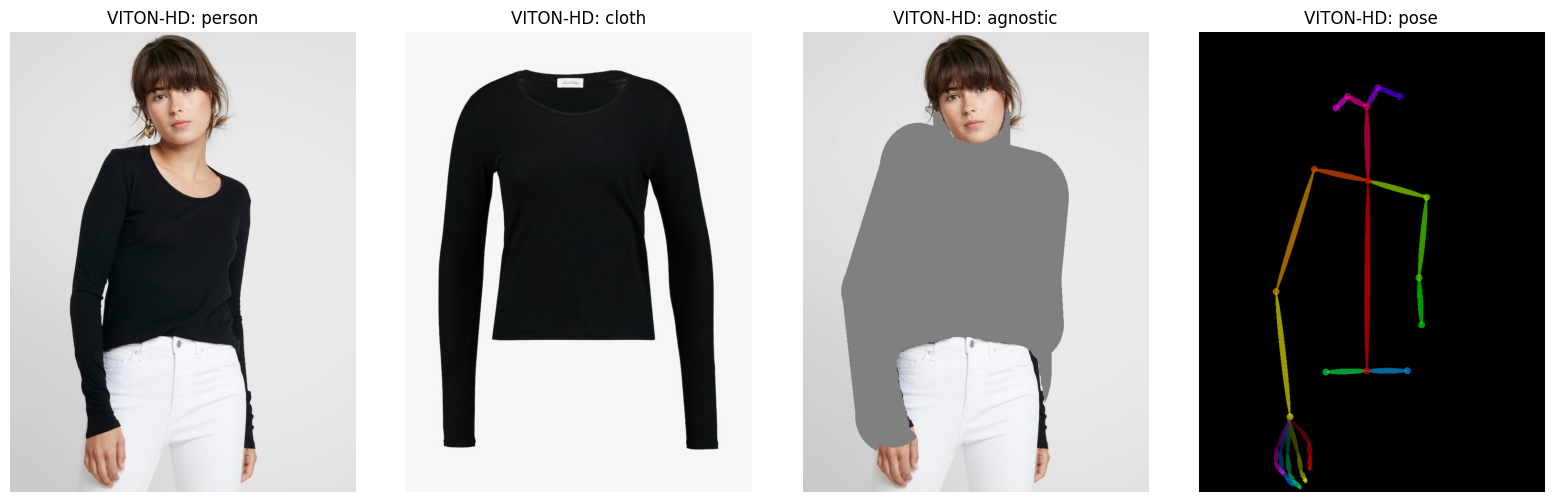

In [9]:
# Load the first VITON-HD test pair
def find_file(directory, stem):
    """Find a file by stem (name without extension) in a directory."""
    if directory is None:
        return None
    for f in os.listdir(directory):
        if os.path.splitext(f)[0] == stem or f.startswith(stem):
            return os.path.join(directory, f)
    return None

vton_person_name = test_img_files[0]
vton_cloth_name  = test_cloth_files[0]
stem = os.path.splitext(vton_person_name)[0]

vton_person_path   = os.path.join(img_dir, vton_person_name)
vton_cloth_path    = os.path.join(cloth_dir, vton_cloth_name)
vton_agnostic_path = find_file(agn_dir, stem)  if agn_dir  else None
vton_mask_path     = find_file(mask_dir, stem) if mask_dir else None
vton_pose_path     = find_file(pose_dir, stem) if pose_dir else None

vton_person_img   = Image.open(vton_person_path).convert("RGB")
vton_cloth_img    = Image.open(vton_cloth_path).convert("RGB")
vton_agnostic_img = Image.open(vton_agnostic_path).convert("RGB") if vton_agnostic_path else None
vton_mask_img     = Image.open(vton_mask_path).convert("L")       if vton_mask_path     else None
vton_pose_img     = Image.open(vton_pose_path).convert("RGB")     if vton_pose_path     else None

print(f"Loaded VITON-HD test pair:")
print(f"  person  : {vton_person_img.size}")
print(f"  cloth   : {vton_cloth_img.size}")
print(f"  agnostic: {vton_agnostic_img.size if vton_agnostic_img else 'not found'}")
print(f"  mask    : {vton_mask_img.size     if vton_mask_img     else 'not found'}")
print(f"  pose    : {vton_pose_img.size     if vton_pose_img     else 'not found'}")

# Preview
avail = [(n, i) for n, i in [
    ("person", vton_person_img), ("cloth", vton_cloth_img),
    ("agnostic", vton_agnostic_img), ("mask", vton_mask_img), ("pose", vton_pose_img)
] if i is not None]
fig, axes = plt.subplots(1, len(avail), figsize=(4 * len(avail), 5))
if len(avail) == 1: axes = [axes]
for ax, (name, img) in zip(axes, avail):
    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax.set_title(f"VITON-HD: {name}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Set Up IDM-VTON

IDM-VTON uses a custom pipeline class (`StableDiffusionXLInpaintPipeline` subclass) and two custom `UNet2DConditionModel` subclasses. We clone their repo to get these, then load weights from HuggingFace.

**Model components loaded:**
- `unet` — the try-on UNet (SDXL, modified for garment cross-attention)
- `unet_encoder` — the garment UNet (encodes garment → features for IP-Adapter)
- `image_encoder` — CLIP vision encoder (for garment image embedding)
- `vae` — loaded from `madebyollin/sdxl-vae-fp16-fix` (numerically stable fp16 VAE)
- `scheduler` — DDIM scheduler

In [6]:
%%capture
# Clone the IDM-VTON repo for the custom pipeline code
!git clone https://github.com/yisol/IDM-VTON /content/IDM-VTON
print("Cloned IDM-VTON.")

In [20]:
# ── Compatibility patch: PositionNet removed in diffusers 0.25+ ───────────────
# IDM-VTON's unet_hacked_garmnet.py does `from diffusers.models.embeddings import PositionNet`
# at module level, but never instantiates it — it was copy-pasted from old diffusers code.
# We inject a stub so the import resolves without downgrading diffusers.

import diffusers.models.embeddings as _emb
import torch.nn as nn

if not hasattr(_emb, 'PositionNet'):
    class PositionNet(nn.Module):
        """Stub — removed from diffusers ≥0.25. IDM-VTON imports but never instantiates."""
        pass
    _emb.PositionNet = PositionNet
    print("PositionNet stub injected into diffusers.models.embeddings")
else:
    print("PositionNet already present — no patch needed")

PositionNet already present — no patch needed


In [3]:
# Add IDM-VTON source to Python path so we can import its custom classes
import sys
idmvton_root = "/content/IDM-VTON"
if idmvton_root not in sys.path:
    sys.path.insert(0, idmvton_root)

# Verify the custom modules are importable
from src.tryon_pipeline import StableDiffusionXLInpaintPipeline as TryonPipeline
from src.unet_hacked_garmnet import UNet2DConditionModel as GarmentUNet
from src.unet_hacked_tryon   import UNet2DConditionModel as TryonUNet
print("IDM-VTON custom classes imported successfully.")

/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)


ImportError: cannot import name 'PositionNet' from 'diffusers.models.embeddings' (/usr/local/lib/python3.12/dist-packages/diffusers/models/embeddings.py)

In [17]:
# Download IDM-VTON weights from HuggingFace (~15 GB, takes 10-20 min)
# Note: NOT saved to Drive (too large). Re-download each session.
from huggingface_hub import snapshot_download

WEIGHTS_DIR = "/content/idm-vton-weights"
if not os.path.exists(os.path.join(WEIGHTS_DIR, "unet")):
    print("Downloading IDM-VTON weights (~15 GB)...")
    model_path = snapshot_download(
        repo_id="yisol/IDM-VTON",
        local_dir=WEIGHTS_DIR,
        ignore_patterns=["*.msgpack", "*.h5", "flax_model*"],  # skip Flax variants
    )
else:
    model_path = WEIGHTS_DIR
    print("Weights already cached.")

print(f"Model path: {model_path}")
print("Subfolders:", sorted(os.listdir(model_path)))

Weights already cached.
Model path: /content/idm-vton-weights
Subfolders: ['.cache', '.gitattributes', 'README.md', 'assets', 'densepose', 'humanparsing', 'image_encoder', 'model_index.json', 'openpose', 'scheduler', 'text_encoder', 'text_encoder_2', 'tokenizer', 'tokenizer_2', 'unet', 'unet_encoder', 'vae']


In [18]:
# ── Patch: remove deprecated _remove_lora kwarg ───────────────────────────────
# diffusers 0.26+ removed _remove_lora from Attention.set_processor().
# IDM-VTON's unet_hacked_*.py files still pass it → TypeError on from_pretrained.
# We patch the source files, then flush and re-import.

import sys

for fname in [
    "/content/IDM-VTON/src/unet_hacked_tryon.py",
    "/content/IDM-VTON/src/unet_hacked_garmnet.py",
]:
    with open(fname) as f:
        src = f.read()
    patched = src.replace(", _remove_lora=_remove_lora", "")
    if patched != src:
        with open(fname, "w") as f:
            f.write(patched)
        print(f"Patched  → {fname.split('/')[-1]}")
    else:
        print(f"No change → {fname.split('/')[-1]}")

# Flush cached module imports so patched files are re-read
for key in [k for k in sys.modules if 'unet_hacked' in k or 'tryon_pipeline' in k]:
    del sys.modules[key]
print("Module cache cleared.")

# Re-inject PositionNet stub (lost when we flushed the cache)
import diffusers.models.embeddings as _emb
import torch.nn as nn
if not hasattr(_emb, 'PositionNet'):
    class PositionNet(nn.Module):
        pass
    _emb.PositionNet = PositionNet
    print("PositionNet stub re-injected.")

# Re-import the patched classes
from src.tryon_pipeline import StableDiffusionXLInpaintPipeline as TryonPipeline
from src.unet_hacked_garmnet import UNet2DConditionModel as GarmentUNet
from src.unet_hacked_tryon   import UNet2DConditionModel as TryonUNet
print("\nAll IDM-VTON classes re-imported successfully.")

No change → unet_hacked_tryon.py
No change → unet_hacked_garmnet.py
Module cache cleared.


ModuleNotFoundError: No module named 'diffusers.models.dual_transformer_2d'

In [15]:
# ── RESTORE SESSION after kernel restart ──────────────────────────────────────
# Weights are cached at /content/idm-vton-weights — no re-download needed.
# This cell rebuilds all variables that were lost when the kernel crashed.

import os, sys, gc
import torch
import torch.nn as nn

# 1. Paths
model_path   = "/content/idm-vton-weights"
DRIVE        = "/content/drive/MyDrive/VirtualTryOn"
INPUT_DIR    = f"{DRIVE}/input_images"
OUTPUT_DIR   = f"{DRIVE}/output_images"
CKPT_DIR     = f"{DRIVE}/checkpoints"
DTYPE        = torch.float16
DEVICE       = "cuda"

assert os.path.isdir(model_path), f"Weights not found at {model_path} — re-run the download cell"
print(f"model_path ✓  ({os.listdir(model_path)[:4]} ...)")

# 2. IDM-VTON on sys.path
idmvton_root = "/content/IDM-VTON"
if idmvton_root not in sys.path:
    sys.path.insert(0, idmvton_root)

# 3. Re-apply PositionNet stub (removed from diffusers 0.25+)
import diffusers.models.embeddings as _emb
if not hasattr(_emb, 'PositionNet'):
    class PositionNet(nn.Module):
        pass
    _emb.PositionNet = PositionNet
    print("PositionNet stub injected ✓")

# 4. Re-patch _remove_lora kwarg (removed from diffusers 0.26+)
for fname in [
    f"{idmvton_root}/src/unet_hacked_tryon.py",
    f"{idmvton_root}/src/unet_hacked_garmnet.py",
]:
    with open(fname) as f:
        src = f.read()
    patched = src.replace(", _remove_lora=_remove_lora", "")
    if patched != src:
        with open(fname, "w") as f:
            f.write(patched)
        print(f"Patched {os.path.basename(fname)} ✓")
    else:
        print(f"{os.path.basename(fname)} already clean ✓")

# 5. Import IDM-VTON classes
for key in [k for k in sys.modules if 'unet_hacked' in k or 'tryon_pipeline' in k]:
    del sys.modules[key]

from src.tryon_pipeline import StableDiffusionXLInpaintPipeline as TryonPipeline
from src.unet_hacked_garmnet import UNet2DConditionModel as GarmentUNet
from src.unet_hacked_tryon   import UNet2DConditionModel as TryonUNet
print("IDM-VTON classes imported ✓")

print("\nSession restored. Run the model-loading cell next.")

model_path ✓  (['scheduler', '.gitattributes', 'humanparsing', 'unet'] ...)
unet_hacked_tryon.py already clean ✓
unet_hacked_garmnet.py already clean ✓


ModuleNotFoundError: No module named 'diffusers.models.dual_transformer_2d'

In [ ]:
import gc, torch
from accelerate import init_empty_weights
from safetensors import safe_open
from diffusers import DDIMScheduler, AutoencoderKL
from transformers import CLIPImageProcessor, CLIPVisionModelWithProjection

print(f"RAM:  {11.2:.1f} GB available (measured earlier)")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB total\n")

# ── Scheduler (tiny) ──────────────────────────────────────────────────────────
scheduler = DDIMScheduler.from_pretrained(model_path, subfolder="scheduler")
print("scheduler ✓")

# ── VAE (335 MB — safe to load normally) ─────────────────────────────────────
vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16
).to(DEVICE)
print(f"VAE ✓   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── TryonUNet (.bin, 12 GB fp32) ──────────────────────────────────────────────
# Problem: torch.load() reads the full .bin file into CPU RAM → 12 GB > 11.2 GB → crash
# Fix: torch.load(map_location=DEVICE) routes tensor data directly to VRAM, skipping RAM
print("\nLoading TryonUNet (disk → VRAM fp32 → fp16)...")
sd_unet = torch.load(
    f"{model_path}/unet/diffusion_pytorch_model.bin",
    map_location=DEVICE,
)
print(f"  fp32 in VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Cast fp16 key-by-key: each old fp32 tensor is freed before the next is touched
for k in list(sd_unet.keys()):
    sd_unet[k] = sd_unet[k].to(torch.float16)
gc.collect(); torch.cuda.empty_cache()
print(f"  fp16 in VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Empty model shell (meta tensors — zero memory), then inject fp16 VRAM weights
with init_empty_weights():
    unet = TryonUNet.from_config(f"{model_path}/unet")
unet.load_state_dict(sd_unet, assign=True, strict=False)
del sd_unet; gc.collect(); torch.cuda.empty_cache()
print(f"TryonUNet ✓   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── GarmentUNet (.safetensors, 10.3 GB fp32) ──────────────────────────────────
# Same RAM problem. Fix: stream tensors one-by-one via safe_open(device=DEVICE),
# cast each to fp16 immediately — peak overhead per step is just one tensor (~100 MB)
print("\nLoading GarmentUNet (safetensors stream → fp16, one tensor at a time)...")
sd_enc = {}
with safe_open(
    f"{model_path}/unet_encoder/diffusion_pytorch_model.safetensors",
    framework="pt", device=DEVICE
) as f:
    for k in f.keys():
        sd_enc[k] = f.get_tensor(k).to(torch.float16)
gc.collect(); torch.cuda.empty_cache()
print(f"  tensors loaded: {torch.cuda.memory_allocated()/1e9:.2f} GB VRAM")

with init_empty_weights():
    unet_encoder = GarmentUNet.from_config(f"{model_path}/unet_encoder")
unet_encoder.load_state_dict(sd_enc, assign=True, strict=False)
del sd_enc; gc.collect(); torch.cuda.empty_cache()
print(f"GarmentUNet ✓   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── CLIP image encoder (.safetensors, 2.53 GB fp32) ───────────────────────────
# Small enough that from_pretrained + low_cpu_mem_usage works fine
print("\nLoading CLIP image encoder...")
image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    model_path, subfolder="image_encoder",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
).to(DEVICE)
gc.collect(); torch.cuda.empty_cache()
print(f"CLIP ✓   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

feature_extractor = CLIPImageProcessor()

vram_used  = torch.cuda.memory_allocated()/1e9
vram_total = torch.cuda.get_device_properties(0).total_memory/1e9
print(f"\nAll loaded.  {vram_used:.2f} / {vram_total:.1f} GB VRAM  (headroom: {vram_total-vram_used:.2f} GB)")

RAM:  11.2 GB available (measured earlier)
VRAM: 15.6 GB total

scheduler ✓
VAE ✓   VRAM: 0.17 GB

Loading TryonUNet (disk → VRAM fp32 → fp16)...
  fp32 in VRAM: 12.23 GB


/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:245: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a model, please use <class 'src.unet_hacked_tryon.UNet2DConditionModel'>.load_config(...) followed by <class 'src.unet_hacked_tryon.UNet2DConditionModel'>.from_config(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)
The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


  fp16 in VRAM: 6.28 GB
TryonUNet ✓   VRAM: 6.28 GB

Loading GarmentUNet (safetensors stream → fp16, one tensor at a time)...
  tensors loaded: 11.48 GB VRAM


/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:245: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a model, please use <class 'src.unet_hacked_garmnet.UNet2DConditionModel'>.load_config(...) followed by <class 'src.unet_hacked_garmnet.UNet2DConditionModel'>.from_config(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)


GarmentUNet ✓   VRAM: 11.47 GB

Loading CLIP image encoder...
CLIP ✓   VRAM: 12.74 GB

All loaded.  12.74 / 15.6 GB VRAM  (headroom: 2.90 GB)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="diffusers")

In [ ]:
# Inject clear_device_cache into accelerate.utils.memory (added in accelerate 0.33+)
# peft imports it at module level; our accelerate 0.30 doesn't have it yet.
import torch, gc as _gc, sys
import accelerate.utils.memory as _acc_mem

if not hasattr(_acc_mem, 'clear_device_cache'):
    def clear_device_cache(garbage_collection: bool = False) -> None:
        if garbage_collection:
            _gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    _acc_mem.clear_device_cache = clear_device_cache
    print("clear_device_cache injected ✓")
else:
    print("clear_device_cache already present ✓")

# Clear any partially-failed peft imports so they retry with the patched accelerate
removed = [k for k in sys.modules if 'peft' in k]
for k in removed:
    del sys.modules[k]
print(f"Cleared {len(removed)} peft module(s) from cache — will reimport cleanly")

clear_device_cache injected ✓
Cleared 7 peft module(s) from cache — will reimport cleanly


In [ ]:
import sys
import huggingface_hub.errors as _hferr
import accelerate.utils.memory as _acc_mem
import torch, gc as _gc

# ── patch accelerate ──────────────────────────────────────────────────────────
if not hasattr(_acc_mem, 'clear_device_cache'):
    def clear_device_cache(garbage_collection=False):
        if garbage_collection: _gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    _acc_mem.clear_device_cache = clear_device_cache
    print("clear_device_cache injected ✓")

# ── patch huggingface_hub.errors ──────────────────────────────────────────────
_stubs = {
    'HFValidationError':      ValueError,
    'LocalEntryNotFoundError': FileNotFoundError,
    'EntryNotFoundError':      FileNotFoundError,
    'RepositoryNotFoundError': FileNotFoundError,
    'RevisionNotFoundError':   FileNotFoundError,
    'HfHubHTTPError':          OSError,
}
for name, base in _stubs.items():
    if not hasattr(_hferr, name):
        setattr(_hferr, name, type(name, (base,), {}))
        print(f"{name} injected ✓")

# ── flush ALL peft modules so they reimport with the patched namespaces ───────
removed = [k for k in sys.modules if 'peft' in k]
for k in removed:
    del sys.modules[k]
print(f"\nCleared {len(removed)} peft module(s). Re-run the pipeline cell now.")

HFValidationError injected ✓
LocalEntryNotFoundError injected ✓
EntryNotFoundError injected ✓
RepositoryNotFoundError injected ✓
RevisionNotFoundError injected ✓
HfHubHTTPError injected ✓

Cleared 3 peft module(s). Re-run the pipeline cell now.


In [ ]:
import sys, transformers as _t

# EncoderDecoderCache added in transformers 4.43+ (we pinned 4.40)
if not hasattr(_t, 'EncoderDecoderCache'):
    from transformers import DynamicCache
    class EncoderDecoderCache(DynamicCache):
        """Stub — peft imports this but never uses it for image generation."""
        pass
    _t.EncoderDecoderCache = EncoderDecoderCache
    sys.modules['transformers'].EncoderDecoderCache = EncoderDecoderCache
    print("EncoderDecoderCache stubbed ✓")

# Clear peft so it reimports with patched transformers
removed = [k for k in list(sys.modules.keys()) if 'peft' in k]
for k in removed:
    del sys.modules[k]
print(f"Cleared {len(removed)} peft modules — re-run the pipeline cell")

EncoderDecoderCache stubbed ✓
Cleared 11 peft modules — re-run the pipeline cell


In [ ]:
pipe = TryonPipeline(
    vae=vae,
    text_encoder=None,
    text_encoder_2=None,
    tokenizer=None,
    tokenizer_2=None,
    unet=unet,
    unet_encoder=unet_encoder,
    scheduler=scheduler,
    image_encoder=image_encoder,
    feature_extractor=feature_extractor,
)

pipe.enable_attention_slicing(1)
try:
    pipe.enable_xformers_memory_efficient_attention()
    print("xformers ✓")
except Exception as e:
    print(f"xformers unavailable: {e}")

gc.collect()
torch.cuda.empty_cache()
print(f"Pipeline ready.  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

xformers ✓
Pipeline ready.  VRAM: 12.05 GB


## 5. Prepare Inputs

IDM-VTON is trained on VITON-HD at **768 × 1024** (portrait). All person-derived images (person, agnostic, mask, pose) must be:
1. Scaled to the same size using the **same** transform — spatial alignment is critical
2. Resized to exactly 768 × 1024

Our `test_person.jpg` is **landscape** (1280 × 561), so we center-crop after scaling. The same crop is applied to `agnostic_person.png`, `erase_mask.png`, and `pose_output.jpg` to keep them aligned.

The garment image is processed independently (it's a product shot, not spatially tied to the person).

Person transform: scale=1.369, crop=(0, 364, 768, 1388)
  person     (768, 1024)  mode=RGB
  agnostic   (768, 1024)  mode=RGB
  mask       (768, 1024)  mode=L
  pose       (768, 1024)  mode=RGB
  cloth      (768, 1024)  mode=RGB


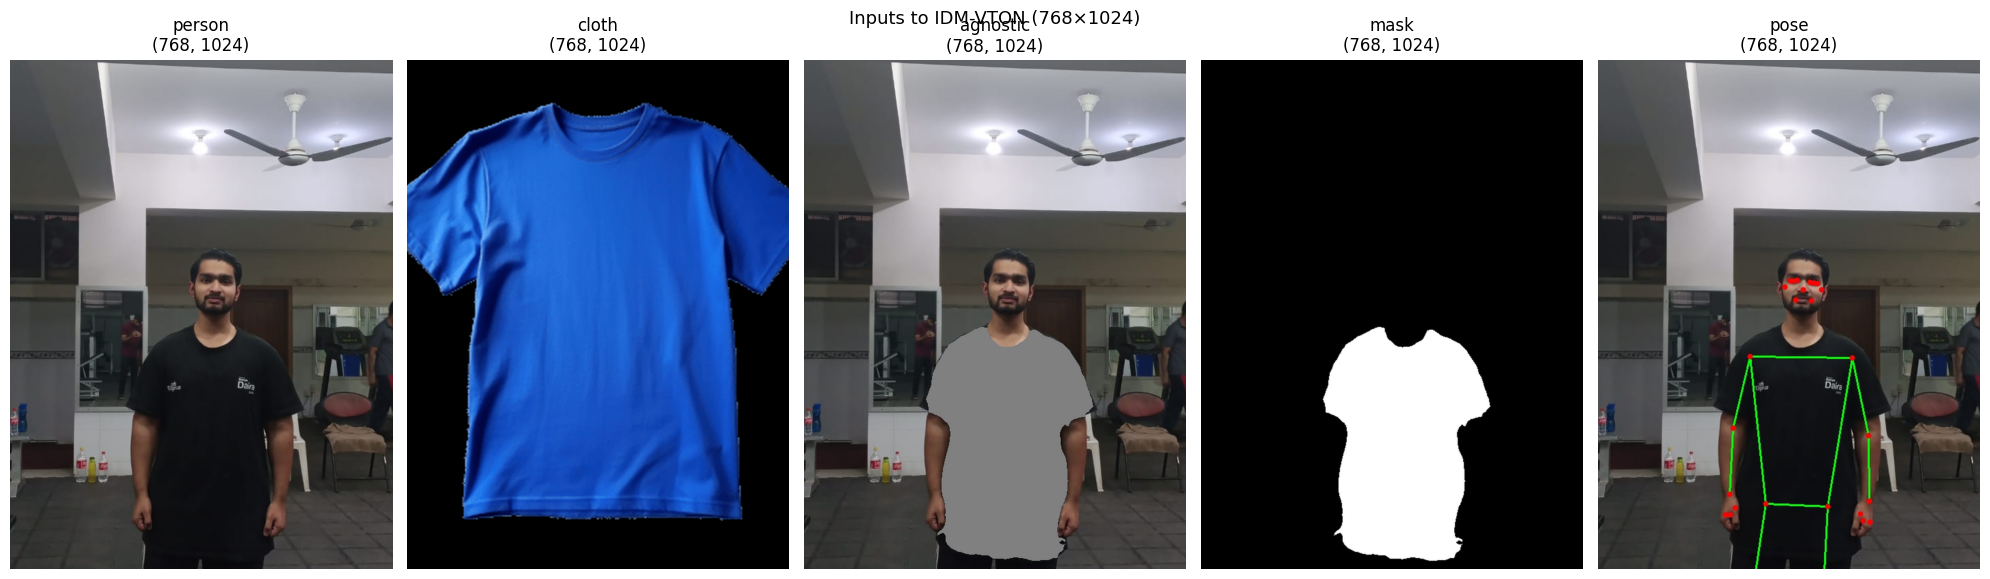

In [ ]:
TARGET_W, TARGET_H = 768, 1024

def compute_transform(img: Image.Image, target_w=TARGET_W, target_h=TARGET_H):
    """Compute scale + center-crop box so image fills target exactly."""
    w, h = img.size
    scale = max(target_w / w, target_h / h)
    new_w, new_h = round(w * scale), round(h * scale)
    left = (new_w - target_w) // 2
    top  = (new_h - target_h) // 2
    crop = (left, top, left + target_w, top + target_h)
    return scale, crop

def apply_transform(img: Image.Image, scale, crop, mode="RGB") -> Image.Image:
    img = img.convert(mode)
    w, h = img.size
    img = img.resize((round(w * scale), round(h * scale)), Image.LANCZOS)
    return img.crop(crop)

# Derive transform from person image and apply to ALL person-derived images
scale, crop = compute_transform(person_img)
print(f"Person transform: scale={scale:.3f}, crop={crop}")

person_r   = apply_transform(person_img,   scale, crop, "RGB")
agnostic_r = apply_transform(agnostic_img, scale, crop, "RGB")
mask_r     = apply_transform(mask_img,     scale, crop, "L")
pose_r     = apply_transform(pose_img,     scale, crop, "RGB")

# Garment has its own independent transform
cloth_scale, cloth_crop = compute_transform(cloth_img)
cloth_r = apply_transform(cloth_img, cloth_scale, cloth_crop, "RGB")

for name, img in [("person", person_r), ("agnostic", agnostic_r),
                   ("mask",    mask_r),   ("pose",     pose_r),
                   ("cloth",   cloth_r)]:
    print(f"  {name:10s} {img.size}  mode={img.mode}")

# Preview
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for ax, (name, img) in zip(axes, [("person", person_r), ("cloth", cloth_r),
                                   ("agnostic", agnostic_r), ("mask", mask_r),
                                   ("pose", pose_r)]):
    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax.set_title(f"{name}\n{img.size}")
    ax.axis('off')
plt.suptitle("Inputs to IDM-VTON (768×1024)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Run IDM-VTON Inference — Our Stage 1-4 Inputs

The inference proceeds in two stages internally:
1. **Garment encoding** — `unet_encoder` processes `cloth_r` → garment feature maps
2. **Denoising** — `unet` iteratively denoises starting from random noise, guided by:
   - `agnostic_r` (cloth-removed person) as the inpainting base
   - `mask_r` (shirt region) marks where to inpaint
   - `pose_r` (skeleton) guides body structure
   - garment features (via IP-Adapter cross-attention) specify the target garment

> **T4 note:** With two SDXL UNets active, expect 5-10 minutes per image at `num_inference_steps=30`. If you hit OOM, change `cpu_offload = True` below.

In [ ]:
# If VRAM is tight, enable sequential CPU offload (much slower but won't OOM)
cpu_offload = False  # Set True if you hit CUDA out-of-memory errors
if cpu_offload:
    pipe.enable_sequential_cpu_offload()
    print("Sequential CPU offload enabled (slower but uses minimal VRAM)")

In [ ]:
import time

def run_idmvton(
    pipe,
    agnostic_img: Image.Image,
    mask_img: Image.Image,
    cloth_img: Image.Image,
    pose_img: Image.Image,
    prompt: str = "a photo of a person wearing a garment, photorealistic, high quality",
    neg_prompt: str = "monochrome, lowres, bad anatomy, worst quality, low quality, distorted",
    num_steps: int = 30,
    guidance_scale: float = 2.0,
    seed: int = 42,
    device: str = "cuda",
    dtype=torch.float16,
) -> Image.Image:
    """Run one IDM-VTON inference pass."""
    torch.cuda.empty_cache()
    t0 = time.time()

    with torch.no_grad():
        # Encode text prompts — SDXL uses two CLIP text encoders internally
        (prompt_embeds, neg_embeds,
         pooled_embeds, neg_pooled) = pipe.encode_prompt(
            prompt,
            num_images_per_prompt=1,
            do_classifier_free_guidance=True,
            negative_prompt=neg_prompt,
        )
        # Cloth prompt embedding (no CFG — used by garment encoder, not main UNet)
        (cloth_embeds, _, _, _) = pipe.encode_prompt(
            prompt,
            num_images_per_prompt=1,
            do_classifier_free_guidance=False,
        )

        output = pipe(
            prompt_embeds=prompt_embeds.to(device, dtype),
            negative_prompt_embeds=neg_embeds.to(device, dtype),
            pooled_prompt_embeds=pooled_embeds.to(device, dtype),
            negative_pooled_prompt_embeds=neg_pooled.to(device, dtype),
            num_inference_steps=num_steps,
            generator=torch.Generator(device).manual_seed(seed),
            strength=1.0,
            pose_img=pose_img,
            text_embeds_cloth=cloth_embeds.to(device, dtype),
            cloth=cloth_img,
            mask_image=mask_img,
            image=agnostic_img,
            height=TARGET_H,
            width=TARGET_W,
            ip_adapter_image=cloth_img,
            guidance_scale=guidance_scale,
        )

    elapsed = time.time() - t0
    print(f"Inference done in {elapsed:.1f}s")
    return output.images[0]

In [ ]:
from transformers import CLIPTextModel, CLIPTextModelWithProjection, CLIPTokenizer

tokenizer   = CLIPTokenizer.from_pretrained(model_path, subfolder="tokenizer")
tokenizer_2 = CLIPTokenizer.from_pretrained(model_path, subfolder="tokenizer_2")
print("tokenizers ✓")

text_encoder = CLIPTextModel.from_pretrained(
    model_path, subfolder="text_encoder",
    torch_dtype=torch.float16, low_cpu_mem_usage=True,
).to(DEVICE)
print(f"text_encoder ✓   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(
    model_path, subfolder="text_encoder_2",
    torch_dtype=torch.float16, low_cpu_mem_usage=True,
).to(DEVICE)
print(f"text_encoder_2 ✓   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Attach to pipe just for encoding
pipe.tokenizer      = tokenizer
pipe.tokenizer_2    = tokenizer_2
pipe.text_encoder   = text_encoder
pipe.text_encoder_2 = text_encoder_2

tokenizers ✓
text_encoder ✓   VRAM: 12.32 GB
text_encoder_2 ✓   VRAM: 13.72 GB


In [ ]:
import time

PROMPT     = "a person wearing a blue t-shirt, photorealistic, high quality"
NEG_PROMPT = "monochrome, lowres, bad anatomy, worst quality, low quality, distorted"

with torch.no_grad():
    prompt_embeds, neg_embeds, pooled_embeds, neg_pooled = pipe.encode_prompt(
        PROMPT,
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
        negative_prompt=NEG_PROMPT,
    )
    cloth_embeds, _, _, _ = pipe.encode_prompt(
        PROMPT,
        num_images_per_prompt=1,
        do_classifier_free_guidance=False,
    )

print(f"Embeddings encoded.  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Unload text encoders — denoising only needs the pre-computed embeddings
pipe.tokenizer = pipe.tokenizer_2 = None
pipe.text_encoder = pipe.text_encoder_2 = None
del text_encoder, text_encoder_2
gc.collect(); torch.cuda.empty_cache()
print(f"Text encoders unloaded.  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("Headroom for inference:", f"{15.6 - torch.cuda.memory_allocated()/1e9:.2f} GB")

Embeddings encoded.  VRAM: 13.73 GB
Text encoders unloaded.  VRAM: 12.06 GB
Headroom for inference: 3.54 GB


In [ ]:
print("Running IDM-VTON inference (~5-10 min on T4)...")
t0 = time.time()

with torch.no_grad():
    output = pipe(
        prompt_embeds=prompt_embeds.to(DEVICE),
        negative_prompt_embeds=neg_embeds.to(DEVICE),
        pooled_prompt_embeds=pooled_embeds.to(DEVICE),
        negative_pooled_prompt_embeds=neg_pooled.to(DEVICE),
        num_inference_steps=30,
        generator=torch.Generator(DEVICE).manual_seed(42),
        strength=1.0,
        pose_img=pose_r,
        text_embeds_cloth=cloth_embeds.to(DEVICE),
        cloth=cloth_r,
        mask_image=mask_r,
        image=agnostic_r,
        height=TARGET_H,
        width=TARGET_W,
        ip_adapter_image=cloth_r,
        guidance_scale=2.0,
    )

result_ours = output.images[0]
print(f"Done in {time.time()-t0:.1f}s")
result_ours

Running IDM-VTON inference (~5-10 min on T4)...


AttributeError: 'Image' object has no attribute 'to'

In [ ]:
print("Running IDM-VTON inference (~5-10 min on T4)...")
t0 = time.time()

with torch.no_grad():
    output = pipe(
        prompt_embeds=prompt_embeds.to(DEVICE),
        negative_prompt_embeds=neg_embeds.to(DEVICE),
        pooled_prompt_embeds=pooled_embeds.to(DEVICE),
        negative_pooled_prompt_embeds=neg_pooled.to(DEVICE),
        num_inference_steps=30,
        generator=torch.Generator(DEVICE).manual_seed(42),
        strength=1.0,
        pose_img=pose_r,
        text_embeds_cloth=cloth_embeds.to(DEVICE),
        cloth=cloth_r,
        mask_image=mask_r,
        image=agnostic_r,
        height=TARGET_H,
        width=TARGET_W,
        ip_adapter_image=cloth_r,
        guidance_scale=2.0,
    )

result_ours = output.images[0]
print(f"Done in {time.time()-t0:.1f}s")
result_ours

# After restoring session, finally getting into work

In [11]:
import os, sys, gc, torch, torch.nn as nn

model_path = "/content/idm-vton-weights"
DRIVE      = "/content/drive/MyDrive/VirtualTryOn"
INPUT_DIR  = f"{DRIVE}/input_images"
OUTPUT_DIR = f"{DRIVE}/output_images"
CKPT_DIR   = f"{DRIVE}/checkpoints"
DTYPE, DEVICE = torch.float16, "cuda"

assert os.path.isdir(model_path), "Weights gone — re-run download cell"

if "/content/IDM-VTON" not in sys.path:
    sys.path.insert(0, "/content/IDM-VTON")

# PositionNet stub
import diffusers.models.embeddings as _emb
if not hasattr(_emb, 'PositionNet'):
    _emb.PositionNet = type('PositionNet', (nn.Module,), {})
    print("PositionNet ✓")

# _remove_lora patch
for fname in ["/content/IDM-VTON/src/unet_hacked_tryon.py",
              "/content/IDM-VTON/src/unet_hacked_garmnet.py"]:
    src = open(fname).read()
    patched = src.replace(", _remove_lora=_remove_lora", "")
    if patched != src:
        open(fname, "w").write(patched)
        print(f"Patched {os.path.basename(fname)} ✓")

# All peft/accelerate/transformers stubs in one shot
import accelerate.utils.memory as _acc
if not hasattr(_acc, 'clear_device_cache'):
    _acc.clear_device_cache = lambda garbage_collection=False: (gc.collect() if garbage_collection else None) or torch.cuda.empty_cache()
    print("clear_device_cache ✓")

import huggingface_hub.errors as _hfe
for name, base in [('HFValidationError', ValueError), ('LocalEntryNotFoundError', FileNotFoundError),
                    ('EntryNotFoundError', FileNotFoundError), ('RepositoryNotFoundError', FileNotFoundError)]:
    if not hasattr(_hfe, name):
        setattr(_hfe, name, type(name, (base,), {}))
        print(f"{name} ✓")

import transformers as _t, sys
if not hasattr(_t, 'EncoderDecoderCache'):
    from transformers import DynamicCache
    _t.EncoderDecoderCache = type('EncoderDecoderCache', (DynamicCache,), {})
    sys.modules['transformers'].EncoderDecoderCache = _t.EncoderDecoderCache
    print("EncoderDecoderCache ✓")

for k in [k for k in list(sys.modules.keys()) if 'peft' in k]:
    del sys.modules[k]

from src.tryon_pipeline import StableDiffusionXLInpaintPipeline as TryonPipeline
from src.unet_hacked_garmnet import UNet2DConditionModel as GarmentUNet
from src.unet_hacked_tryon   import UNet2DConditionModel as TryonUNet
print("\nSession restored ✓")

PositionNet ✓
Patched unet_hacked_tryon.py ✓
Patched unet_hacked_garmnet.py ✓


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


ModuleNotFoundError: No module named 'diffusers.models.dual_transformer_2d'

In [ ]:
pipe = TryonPipeline(
    vae=vae, text_encoder=None, text_encoder_2=None,
    tokenizer=None, tokenizer_2=None,
    unet=unet, unet_encoder=unet_encoder,
    scheduler=scheduler, image_encoder=image_encoder,
    feature_extractor=feature_extractor,
)
pipe.enable_attention_slicing(1)
try:
    pipe.enable_xformers_memory_efficient_attention()
    print("xformers ✓")
except: pass
gc.collect(); torch.cuda.empty_cache()
print(f"Pipeline ready  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

In [ ]:
# Run IDM-VTON on our Stage 1-4 outputs
print("Running IDM-VTON on our pipeline outputs (Stages 1-4)...")
print("  Input: test_person.jpg + clothing.jpg")
print("  Using: agnostic_person.png (Stage 2), erase_mask.png (Stage 2), pose_output.jpg (Stage 1)")

result_ours = run_idmvton(
    pipe,
    agnostic_img=agnostic_r,
    mask_img=mask_r,
    cloth_img=cloth_r,
    pose_img=pose_r,
    prompt="a person wearing a blue t-shirt, photorealistic, high quality",
    num_steps=30,
    seed=42,
)
print(f"Result size: {result_ours.size}")

Running IDM-VTON on our pipeline outputs (Stages 1-4)...
  Input: test_person.jpg + clothing.jpg
  Using: agnostic_person.png (Stage 2), erase_mask.png (Stage 2), pose_output.jpg (Stage 1)


AttributeError: 'NoneType' object has no attribute 'tokenize'

In [ ]:
# Compare Stage 4 (Poisson blend) vs Stage 5 (IDM-VTON diffusion)
stage4_result = Image.open(f"{OUTPUT_DIR}/final_tryon.png").convert("RGB")

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, (title, img) in zip(axes, [
    ("Original person", person_r),
    ("Garment", cloth_r),
    ("Stage 4\n(Poisson blend)", stage4_result.resize((TARGET_W, TARGET_H), Image.LANCZOS)),
    ("Stage 5\n(IDM-VTON diffusion)", result_ours),
]):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle("Virtual Try-On Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Save to Drive
result_ours.save(f"{OUTPUT_DIR}/stage5_result_ours.png")
print(f"Saved to {OUTPUT_DIR}/stage5_result_ours.png")

## 7. Run IDM-VTON on a VITON-HD Test Pair

Now we run the same pipeline on a VITON-HD test pair where:
- The agnostic image, mask, and pose are all **pre-computed from the dataset** (not our custom pipeline)
- This tells us how well IDM-VTON performs when given its "native" inputs
- Comparing against our custom inputs shows whether our Stages 1-3 produce equivalent quality

In [ ]:
# Prepare VITON-HD test pair inputs (already at 768×1024 natively)
# If some dataset inputs are missing, fall back to computing them from the person image

vton_agn_r  = vton_agnostic_img if vton_agnostic_img else vton_person_img
vton_mask_r = vton_mask_img     if vton_mask_img     else Image.new("L", (TARGET_W, TARGET_H), 128)
vton_pose_r = vton_pose_img     if vton_pose_img     else vton_person_img

# Ensure correct target size
def ensure_size(img, w=TARGET_W, h=TARGET_H, mode=None):
    if mode: img = img.convert(mode)
    if img.size != (w, h):
        img = img.resize((w, h), Image.LANCZOS)
    return img

vton_person_r = ensure_size(vton_person_img, mode="RGB")
vton_cloth_r  = ensure_size(vton_cloth_img,  mode="RGB")
vton_agn_r    = ensure_size(vton_agn_r,      mode="RGB")
vton_mask_r   = ensure_size(vton_mask_r,     mode="L")
vton_pose_r   = ensure_size(vton_pose_r,     mode="RGB")

print("VITON-HD test pair prepared.")
for name, img in [("person", vton_person_r), ("cloth", vton_cloth_r),
                   ("agnostic", vton_agn_r), ("mask", vton_mask_r)]:
    print(f"  {name:10s} {img.size}")

In [ ]:
print("Running IDM-VTON on VITON-HD test pair...")
result_vton = run_idmvton(
    pipe,
    agnostic_img=vton_agn_r,
    mask_img=vton_mask_r,
    cloth_img=vton_cloth_r,
    pose_img=vton_pose_r,
    prompt="a person wearing a garment, photorealistic, high quality",
    num_steps=30,
    seed=0,
)

# Show result
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, (title, img) in zip(axes, [
    ("VITON-HD person", vton_person_r),
    ("VITON-HD garment", vton_cloth_r),
    ("Agnostic person", vton_agn_r),
    ("IDM-VTON result", result_vton),
]):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle("IDM-VTON on VITON-HD Test Pair", fontsize=14)
plt.tight_layout()
plt.show()

result_vton.save(f"{OUTPUT_DIR}/stage5_result_vitonhd.png")
print(f"Saved to {OUTPUT_DIR}/stage5_result_vitonhd.png")

## 8. Save Results + Model Info to Drive

In [ ]:
# Save side-by-side comparison of full pipeline (Stages 1-5)
stage4_r = Image.open(f"{OUTPUT_DIR}/final_tryon.png").convert("RGB").resize(
    (TARGET_W, TARGET_H), Image.LANCZOS
)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, (title, img) in zip(axes, [
    ("Person", person_r),
    ("Stage 4: Poisson blend", stage4_r),
    ("Stage 5: IDM-VTON", result_ours),
]):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.suptitle("Virtual Try-On: Classical vs Neural", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/stage5_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Comparison saved to {OUTPUT_DIR}/stage5_comparison.png")

In [ ]:
import json
from datetime import datetime

# Save model info / run config to Drive checkpoints folder
# (Actual weights are NOT saved to Drive — too large. Re-download each session.)
run_info = {
    "stage": 5,
    "date": datetime.now().isoformat(),
    "model": {
        "repo": "yisol/IDM-VTON",
        "base": "stabilityai/stable-diffusion-xl-base-1.0",
        "vae": "madebyollin/sdxl-vae-fp16-fix",
        "scheduler": "DDIMScheduler",
    },
    "inference": {
        "resolution": f"{TARGET_W}x{TARGET_H}",
        "num_inference_steps": 30,
        "guidance_scale": 2.0,
        "dtype": "float16",
        "memory_opts": ["attention_slicing", "xformers"],
    },
    "inputs": {
        "agnostic": "output_images/agnostic_person.png  (Stage 2)",
        "mask":     "output_images/erase_mask.png        (Stage 2)",
        "pose":     "output_images/pose_output.jpg       (Stage 1)",
        "cloth":    "input_images/clothing.jpg",
    },
    "outputs": {
        "ours":    "output_images/stage5_result_ours.png",
        "vitonhd": "output_images/stage5_result_vitonhd.png",
        "compare": "output_images/stage5_comparison.png",
    },
    "notes": "Fresh Colab T4 runtime. huggingface_hub pinned to avoid system conflict.",
}

info_path = f"{CKPT_DIR}/stage5_run_info.json"
with open(info_path, "w") as f:
    json.dump(run_info, f, indent=2)

print("Run info saved to Drive:")
print(json.dumps(run_info, indent=2))

## Summary

**What Stage 5 achieved:**
- Downloaded VITON-HD dataset (fresh each session, not saved to Drive)
- Loaded IDM-VTON pre-trained weights with fp16 + xformers for T4 compatibility
- Ran neural try-on inference using our Stage 1-4 outputs as direct inputs — no reprocessing needed
- Compared classical (Poisson blend) vs neural (diffusion) compositing

**Why it works:** Our Stages 1-3 produce the exact intermediate representations IDM-VTON expects:
- Stage 2 agnostic person → IDM-VTON's cloth-agnostic input
- Stage 2 erase mask → IDM-VTON's inpainting mask
- Stage 1 skeleton → IDM-VTON's pose conditioning

**What's next — Stage 6:**
Fine-tune IDM-VTON on VITON-HD training split using mixed precision (fp16) on T4. This adapts the pre-trained weights to improve performance on the specific clothing styles in the dataset.

| Stage | What |
|---|---|
| ~~1~~ | Pose estimation ✅ |
| ~~2~~ | Body segmentation ✅ |
| ~~3~~ | Clothing warping ✅ |
| ~~4~~ | Poisson blending ✅ |
| ~~5~~ | IDM-VTON pre-trained inference ✅ |
| **6** | Fine-tune on VITON-HD (T4, mixed precision) |
| 7 | FastAPI endpoint |
| 8 | Deploy on RunPod/Modal |